# 08 · A new cultivar

Define a new soybean cultivar from Bragg and compare its simulated development and seed yield at Gainesville in 1979.

## You will learn

- Read the source cultivar's ecotype and coefficients.
- Define a new cultivar under your own code using experiment data.
- Compare flowering, maturity and seed yield with the source cultivar.

In [1]:
LESSON = "08_new_cultivar"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Select the copied soybean inputs and preview treatment 1 and its cultivar in the FileX.

In [4]:
# Select the stock inputs and show the treatment and cultivar rows.
inputs = {
    "filex": RUNS / "UFGA7901.SBX",
    "weather": RUNS / "UFGA7901.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
print("Inputs:", ", ".join(inputs[key].relative_to(HERE).as_posix()
                          for key in ("filex", "weather", "soil")))
lines = inputs["filex"].read_text(encoding="utf-8").splitlines()
for section in ("*TREATMENTS", "*CULTIVARS"):
    start = next(i for i, line in enumerate(lines) if line.startswith(section))
    print("\n".join(lines[start:start + 3]))

Inputs: runs/UFGA7901.SBX, runs/UFGA7901.WTH, runs/SOIL.SOL
*TREATMENTS                        -------------FACTOR LEVELS------------
@N R O C TNAME.................... CU FL SA IC MP MI MF MR MC MT ME MH SM
 1 1 0 0 79 IRRIG. BRAGG            1  1  0  1  1  1  0  1  0  0  0  0  1
*CULTIVARS
@C CR INGENO CNAME
 1 SB IB0001 BRAGG


🌱 Crop idea  
Treatment 1 is irrigated Bragg (`IB0001`), planted on 19 June 1979 in Millhopper Fine Sand (`IBSB910015`).
Keep its weather, soil, irrigation and simulation controls fixed to compare only cultivar definitions.

Read Bragg's row from the bundled soybean `.CUL` to identify its ecotype and collect the source coefficients.

In [5]:
# Read the source cultivar's ecotype and all 18 coefficients.
cul = RUNS / "SBGRO048.CUL"
cul_lines = cul.read_text(encoding="utf-8").splitlines()
header = next(line for line in cul_lines if line.startswith("@VAR#"))
source_line = next(line for line in cul_lines if line.startswith("IB0001 "))
coefficient_names = header.split()[4:]
source_coefficients = dict(zip(coefficient_names, map(float, source_line.split()[4:])))
source_ecotype = source_line.split()[3]
print("Source: IB0001 (Bragg); ecotype:", source_ecotype)
print("Genotype inputs:", ", ".join((RUNS / name).relative_to(HERE).as_posix()
                                  for name in ("SBGRO048.CUL", "SBGRO048.ECO", "SBGRO048.SPE")))

Source: IB0001 (Bragg); ecotype: SB0701
Genotype inputs: runs/SBGRO048.CUL, runs/SBGRO048.ECO, runs/SBGRO048.SPE


Type all 18 coefficients for `NC0001`, retaining ecotype `SB0701` and increasing only `EM-FL` from 19.5 to 23.5 photothermal days.

In [6]:
# Define the new cultivar and compare its coefficients with Bragg.
new_cultivar = {
    "crop": "SB", "code": "NC0001", "ecotype": "SB0701", "name": "Bragg later",
    "coefficients": {
        "CSDL": 12.33, "PPSEN": 0.320, "EM-FL": 23.5, "FL-SH": 10.0,
        "FL-SD": 15.2, "SD-PM": 37.60, "FL-LF": 19.00, "LFMAX": 1.000,
        "SLAVR": 355.0, "SIZLF": 170.0, "XFRT": 1.00, "WTPSD": 0.170,
        "SFDUR": 24.0, "SDPDV": 2.00, "PODUR": 10.0, "THRSH": 78.0,
        "SDPRO": 0.400, "SDLIP": 0.200,
    },
}
experiment = {"treatments": {1: {"cultivar": new_cultivar}}}
dl.to_dataframe([{"Coefficient": key, "Bragg": value,
                  "NC0001": new_cultivar["coefficients"][key],
                  "Change": new_cultivar["coefficients"][key] - value}
                 for key, value in source_coefficients.items()])

,Coefficient,Bragg,NC0001,Change
0,CSDL,12.33,12.33,0.0
1,PPSEN,0.32,0.32,0.0
2,EM-FL,19.50,23.50,4.0
3,FL-SH,10.00,10.00,0.0
4,FL-SD,15.20,15.20,0.0
5,SD-PM,37.60,37.60,0.0
6,FL-LF,19.00,19.00,0.0
7,LFMAX,1.00,1.00,0.0
8,SLAVR,355.00,355.00,0.0
9,SIZLF,170.00,170.00,0.0


🌱 Crop idea  
`EM-FL` is emergence to first flower in photothermal days, which account for temperature and day length rather than counting calendar days.
The definitions and units for the other coefficients are visible in the comments at the top of `runs/SBGRO048.CUL`.

🐍 Python idea  
The nested dictionary supplies the cultivar definition for treatment `1` through `management`, which accepts all experiment data.
A new code needs every coefficient and an ecotype; changing coefficients of an existing code instead creates a changed cultivar with a generated `DLnnnn` code.

Build and check the source and new-cultivar Simulations before running either one.

In [7]:
# Check both cultivar definitions against the same stock inputs.
base_sim = dl.Simulation(**inputs, treatment=1)
new_sim = dl.Simulation(**inputs, treatment=1, management=experiment)
base_problems = base_sim.check(verbose=False)
new_problems = new_sim.check(verbose=False)
print("Bragg problems:", base_problems)
print("NC0001 problems:", new_problems)

Bragg problems: []
NC0001 problems: []


Run both cultivars and compare planting (`PDAT`), flowering (`ADAT`), maturity (`MDAT`) and seed yield (`HWAM`, kg/ha).

In [8]:
# Run both cultivars and display their end-of-season results.
base_result = base_sim.run()
new_result = new_sim.run()
base_row = dl.read_summary(base_result.run_dir)[0]
new_row = dl.read_summary(new_result.run_dir)[0]
comparison = dl.to_dataframe([dict(base_row, Cultivar="Bragg (IB0001)"),
                             dict(new_row, Cultivar="Bragg later (NC0001)")])
comparison[["Cultivar", "PDAT", "ADAT", "MDAT", "HWAM"]]

,Cultivar,PDAT,ADAT,MDAT,HWAM
0,Bragg (IB0001),1979-06-19,1979-08-01,1979-10-12,3114
1,Bragg later (NC0001),1979-06-19,1979-08-08,1979-10-16,2974


Inspect the generated cultivar copy to confirm the new code was added and the source genotype inputs stayed unchanged.

In [9]:
# Verify the new code and the unchanged source genotype files.
generated_cul = new_result.run_dir.parent / "SBGRO048.CUL"
generated_lines = generated_cul.read_text(encoding="utf-8").splitlines()
print("Cultivar copy:", generated_cul.relative_to(HERE).as_posix())
print("\n".join(line for line in generated_lines
                if line.startswith(("IB0001 ", "NC0001 "))))
print("Source genotype inputs unchanged:", all(
    (RUNS / name).read_bytes() == (base_result.run_dir.parent / name).read_bytes()
    for name in ("SBGRO048.CUL", "SBGRO048.ECO", "SBGRO048.SPE")))

Cultivar copy: runs/dssat_sim_2026-10-06_202539/SBGRO048.CUL
IB0001 BRAGG                . SB0701 12.33 0.320  19.5  10.0  15.2 37.60 19.00 1.000  355. 170.0  1.00 0.170  24.0  2.00  10.0  78.0  .400  .200
NC0001 Bragg later           .SB0701 12.33  0.32  23.5  10.0  15.2  37.6  19.0   1.0 355.0 170.0   1.0  0.17  24.0   2.0  10.0  78.0   0.4   0.2
Source genotype inputs unchanged: True


Express phenology as days after planting and show the new cultivar's differences from Bragg.

In [10]:
# Compare calendar durations and seed yield without converting photothermal days.
metrics = [
    ("Planting to flowering (days)", (base_row["ADAT"] - base_row["PDAT"]).days,
     (new_row["ADAT"] - new_row["PDAT"]).days),
    ("Planting to maturity (days)", (base_row["MDAT"] - base_row["PDAT"]).days,
     (new_row["MDAT"] - new_row["PDAT"]).days),
    ("Seed yield, HWAM (kg/ha)", base_row["HWAM"], new_row["HWAM"]),
]
dl.to_dataframe([{"Metric": metric, "Bragg": base, "NC0001": new,
                  "New minus Bragg": new - base} for metric, base, new in metrics])

,Metric,Bragg,NC0001,New minus Bragg
0,Planting to flowering (days),43,50,7
1,Planting to maturity (days),115,119,4
2,"Seed yield, HWAM (kg/ha)",3114,2974,-140


🌱 Crop idea  
Increasing `EM-FL` by 4 photothermal days delays flowering by 7 calendar days and maturity by 4 calendar days here; seed yield falls from 3,114 to 2,974 kg/ha (140 kg/ha less).
As in [lesson 07](../07_simulated_vs_observed/lesson.ipynb), compare simulated results with observed data before judging credibility: this hypothetical line is not calibrated.

Plot leaf area index (`LAID`, m² leaf/m² ground) to compare the two simulated canopies over time.

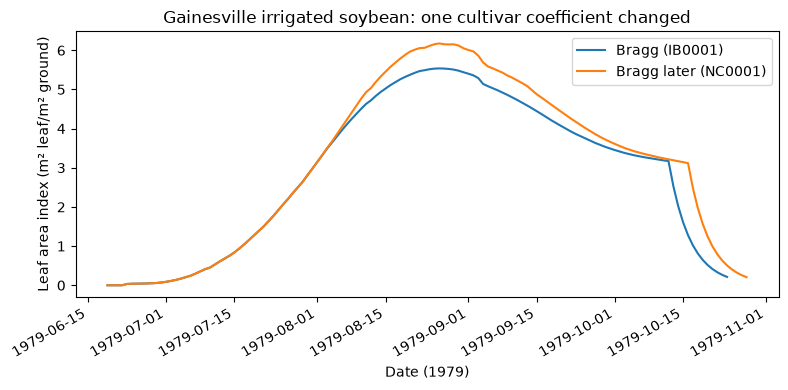

In [11]:
# Plot daily canopy development for both cultivars.
fig, ax = plt.subplots(figsize=(8, 4))
for label, result in (("Bragg (IB0001)", base_result), ("Bragg later (NC0001)", new_result)):
    growth = dl.to_dataframe(dl.read_plant_growth(result.run_dir))
    ax.plot(growth["DATE"], growth["LAID"], label=label)
ax.set(xlabel="Date (1979)", ylabel="Leaf area index (m² leaf/m² ground)",
       title="Gainesville irrigated soybean: one cultivar coefficient changed")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

🌱 Crop idea  
The new line reaches a higher peak leaf area index but yields less seed, which may look surprising.
A larger canopy does not guarantee more seed yield; this plot alone does not establish why yield changed.

## Your turn

Define another new cultivar and compare its development and seed yield with stock Bragg.

Hint: edit `em_fl = 21.5` (photothermal days), then run this cell.

In [12]:
# Rebuild both simulations to test your own emergence-to-flowering coefficient.
em_fl = 21.5
exercise_inputs = {
    "filex": RUNS / "UFGA7901.SBX", "weather": RUNS / "UFGA7901.WTH",
    "soil": RUNS / "SOIL.SOL", "executable": dssat,
}
exercise_cultivar = {
    "crop": "SB", "code": "NC0002", "ecotype": "SB0701", "name": "Bragg exercise",
    "coefficients": {
        "CSDL": 12.33, "PPSEN": 0.320, "EM-FL": em_fl, "FL-SH": 10.0,
        "FL-SD": 15.2, "SD-PM": 37.60, "FL-LF": 19.00, "LFMAX": 1.000,
        "SLAVR": 355.0, "SIZLF": 170.0, "XFRT": 1.00, "WTPSD": 0.170,
        "SFDUR": 24.0, "SDPDV": 2.00, "PODUR": 10.0, "THRSH": 78.0,
        "SDPRO": 0.400, "SDLIP": 0.200,
    },
}
exercise_experiment = {"treatments": {1: {"cultivar": exercise_cultivar}}}
exercise_rows = []
for label, management in (("Bragg (IB0001)", None), ("Your line (NC0002)", exercise_experiment)):
    exercise_sim = dl.Simulation(**exercise_inputs, treatment=1, management=management)
    exercise_result = exercise_sim.run()
    row = dl.read_summary(exercise_result.run_dir)[0]
    exercise_rows.append({
        "Cultivar": label, "Flowering date": row["ADAT"], "Maturity date": row["MDAT"],
        "Flowering (days after planting)": (row["ADAT"] - row["PDAT"]).days,
        "Maturity (days after planting)": (row["MDAT"] - row["PDAT"]).days,
        "Seed yield (kg/ha)": row["HWAM"],
    })
dl.to_dataframe(exercise_rows)

,Cultivar,Flowering date,Maturity date,Flowering (days after planting),Maturity (days after planting),Seed yield (kg/ha)
0,Bragg (IB0001),1979-08-01,1979-10-12,43,115,3114
1,Your line (NC0002),1979-08-05,1979-10-14,47,117,3039


## Recap

- A new cultivar needs an unused code, an existing ecotype and every cultivar coefficient.
- Experiment data adds the new line to a simulation folder's `.CUL` copy while retaining the source inputs.
- Compare development dates and seed yield under the same conditions; observed data are needed to judge credibility.

Next: [09 · Rainfed vs irrigated, automatic irrigation](../09_irrigation/lesson.ipynb).